# Training Run Visualizations

Three sections:
1. **Autoresearch progress** (subset98 and full555) — val/test acc per experiment, keep/discard, running best
2. **Epoch-level curves** (older ResNet50 method) — per-epoch loss and accuracy from `epoch_metrics.csv`
3. **Run summary comparison** (older method) — final val/test acc per run from `run_summary.csv`

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
})

ARTIFACTS = Path('artifacts')

# ── paths ──────────────────────────────────────────────────────────────────
AR98_CSV      = ARTIFACTS / 'autoresearch_log.csv'
AR555_CSV     = ARTIFACTS / 'autoresearch_log_full555.csv'
EPOCH_CSV     = ARTIFACTS / 'logs' / 'epoch_metrics.csv'
SUMMARY_CSV   = ARTIFACTS / 'logs' / 'run_summary.csv'

---
## 1 · Autoresearch progress

Each dot is one experiment. Green = kept (improved), red = discarded, grey = no status recorded.  
The solid line shows the **running best** val accuracy over time.

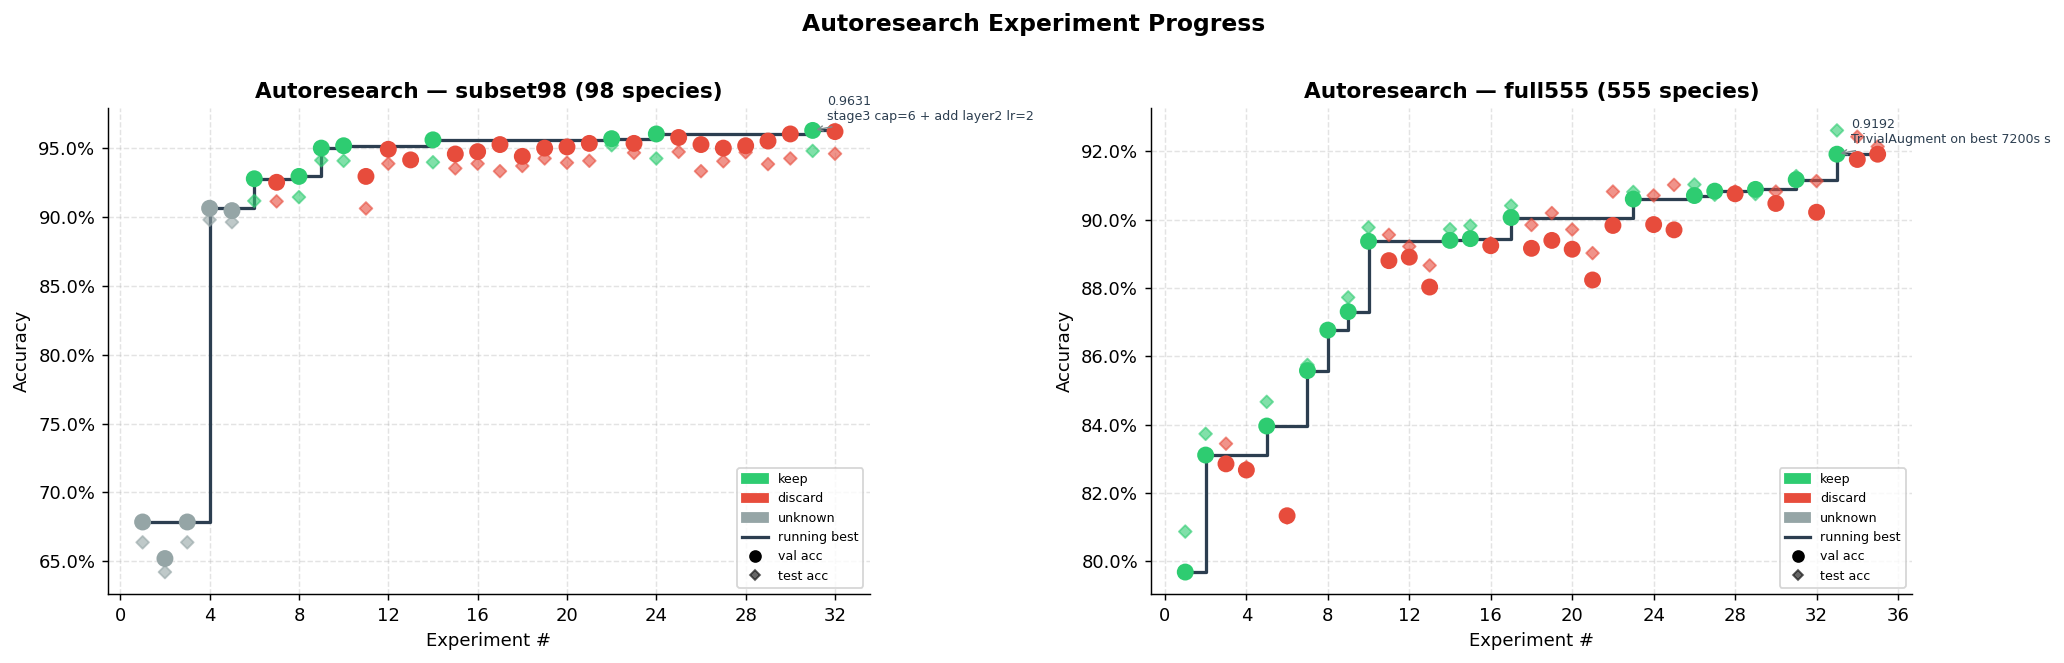

In [2]:
def load_autoresearch(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path, parse_dates=['timestamp'])
    df['val_acc']  = pd.to_numeric(df['top1_val_acc'],  errors='coerce')
    df['test_acc'] = pd.to_numeric(df['top1_test_acc'], errors='coerce')
    df['train_sec'] = pd.to_numeric(df.get('training_seconds', pd.NA), errors='coerce')
    df = df.reset_index(drop=True)
    df['exp_num'] = df.index + 1
    df['running_best'] = df['val_acc'].cummax()
    return df

df98  = load_autoresearch(AR98_CSV)
df555 = load_autoresearch(AR555_CSV)

STATUS_COLORS = {'keep': '#2ecc71', 'discard': '#e74c3c'}
DEFAULT_COLOR = '#95a5a6'

def plot_autoresearch(ax, df, title):
    if df.empty:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return

    colors = df['status'].map(STATUS_COLORS).fillna(DEFAULT_COLOR)

    # dots
    ax.scatter(df['exp_num'], df['val_acc'],  c=colors, s=70, zorder=3, label='val acc')
    ax.scatter(df['exp_num'], df['test_acc'], c=colors, s=25, marker='D', alpha=0.6, zorder=3, label='test acc')

    # running best line
    ax.step(df['exp_num'], df['running_best'], where='post',
            color='#2c3e50', linewidth=1.8, zorder=2, label='running best')

    # annotate the best experiment
    best_idx = df['val_acc'].idxmax()
    best_row = df.loc[best_idx]
    ax.annotate(
        f"{best_row['val_acc']:.4f}\n{str(best_row.get('notes',''))[:30]}",
        xy=(best_row['exp_num'], best_row['val_acc']),
        xytext=(8, 6), textcoords='offset points',
        fontsize=7, color='#2c3e50',
        arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=0.8),
    )

    ax.set_xlabel('Experiment #')
    ax.set_ylabel('Accuracy')
    ax.set_title(title, fontweight='bold')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    patches = [
        mpatches.Patch(color=STATUS_COLORS['keep'],    label='keep'),
        mpatches.Patch(color=STATUS_COLORS['discard'], label='discard'),
        mpatches.Patch(color=DEFAULT_COLOR,            label='unknown'),
        plt.Line2D([0], [0], color='#2c3e50', lw=1.8,  label='running best'),
        plt.Line2D([0], [0], color='k',  marker='o', linestyle='', ms=6, label='val acc'),
        plt.Line2D([0], [0], color='k',  marker='D', linestyle='', ms=4, alpha=0.6, label='test acc'),
    ]
    ax.legend(handles=patches, fontsize=7, loc='lower right')


fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
plot_autoresearch(axes[0], df98,  'Autoresearch — subset98 (98 species)')
plot_autoresearch(axes[1], df555, 'Autoresearch — full555 (555 species)')
fig.suptitle('Autoresearch Experiment Progress', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1b · Training time per experiment

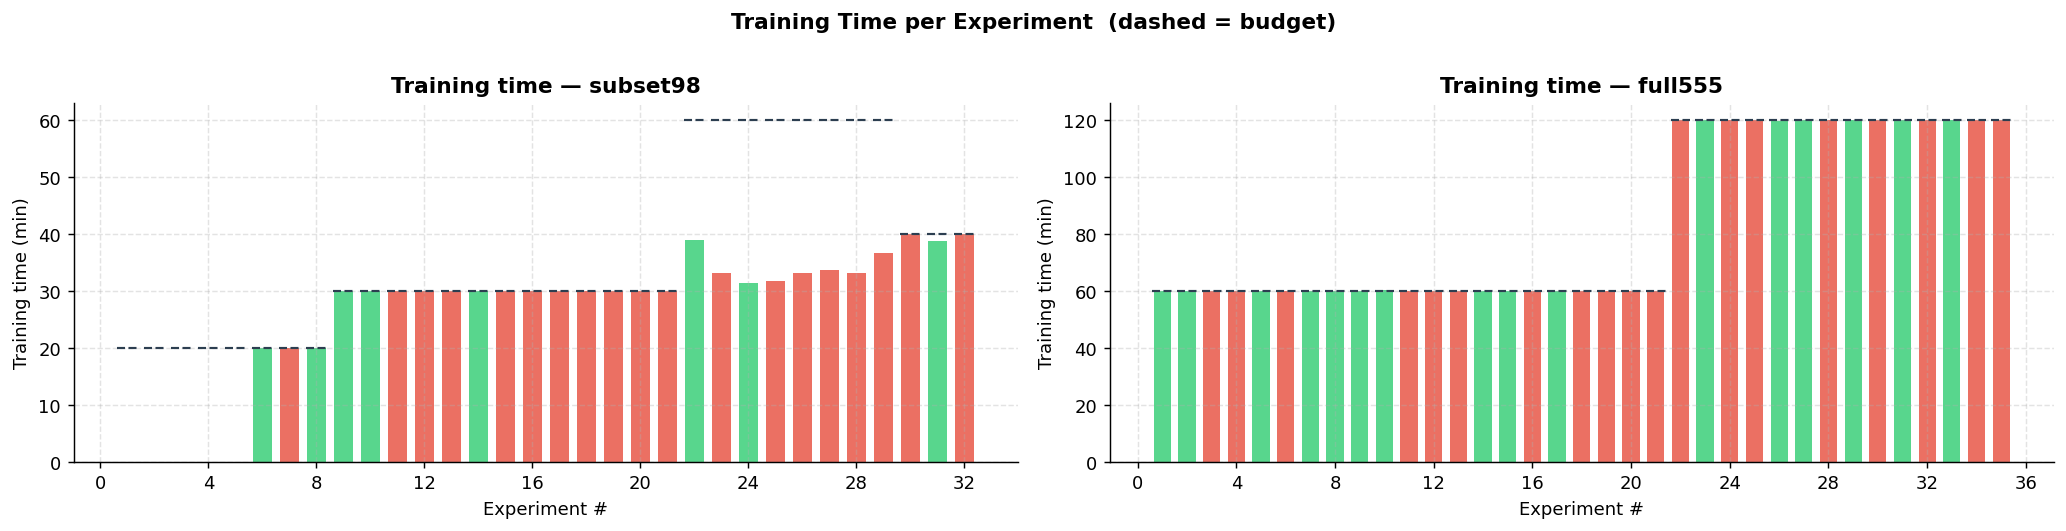

In [3]:
def plot_training_time(ax, df, title):
    if df.empty or df['train_sec'].isna().all():
        ax.text(0.5, 0.5, 'No timing data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    colors = df['status'].map(STATUS_COLORS).fillna(DEFAULT_COLOR)
    minutes = df['train_sec'] / 60
    ax.bar(df['exp_num'], minutes, color=colors, alpha=0.8, width=0.7)
    if 'time_budget_sec' in df.columns:
        budget_min = pd.to_numeric(df['time_budget_sec'], errors='coerce') / 60
        for _, row in df.iterrows():
            if not pd.isna(budget_min[row.name]):
                ax.hlines(budget_min[row.name], row['exp_num'] - 0.4, row['exp_num'] + 0.4,
                          colors='#2c3e50', linewidth=1.2, linestyles='dashed')
    ax.set_xlabel('Experiment #')
    ax.set_ylabel('Training time (min)')
    ax.set_title(title, fontweight='bold')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_training_time(axes[0], df98,  'Training time — subset98')
plot_training_time(axes[1], df555, 'Training time — full555')
fig.suptitle('Training Time per Experiment  (dashed = budget)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1c · Diagnostic analysis flags (subset98)

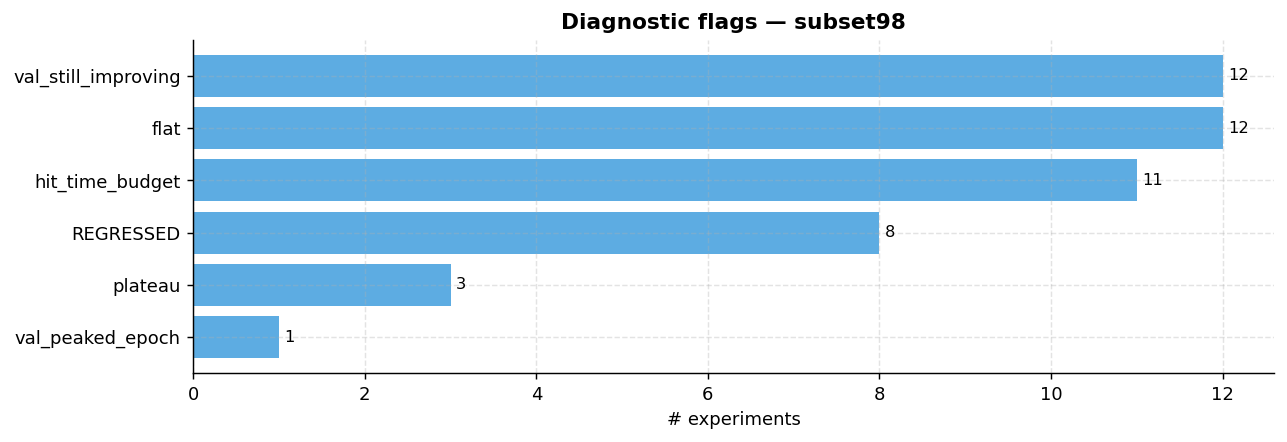

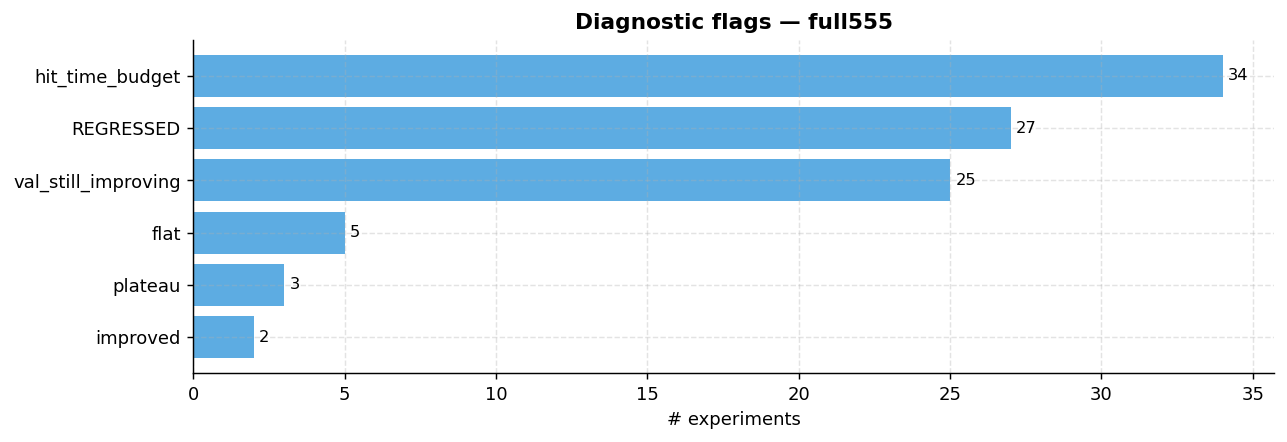

In [4]:
import re
from collections import Counter

FLAG_PATTERNS = [
    'OVERFITTING', 'UNDERFITTING', 'val_still_improving', 'val_peaked_epoch',
    'plateau', 'hit_time_budget', 'REGRESSED', 'improved', r'flat\(',
]

def count_flags(df: pd.DataFrame) -> Counter:
    counts: Counter = Counter()
    if 'analysis' not in df.columns:
        return counts
    for cell in df['analysis'].dropna():
        for pat in FLAG_PATTERNS:
            if re.search(pat, str(cell)):
                label = pat.replace('\\(', '').replace('(', '')
                counts[label] += 1
    return counts

for df, label in [(df98, 'subset98'), (df555, 'full555')]:
    counts = count_flags(df)
    if not counts:
        print(f'{label}: no analysis data')
        continue
    labels, vals = zip(*sorted(counts.items(), key=lambda x: -x[1]))
    fig, ax = plt.subplots(figsize=(10, 3.5))
    bars = ax.barh(labels, vals, color='#3498db', alpha=0.8)
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_xlabel('# experiments')
    ax.set_title(f'Diagnostic flags — {label}', fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()

---
## 2 · Older ResNet50 runs — epoch-level curves

Each panel is one run group. Solid = training, dashed = validation.

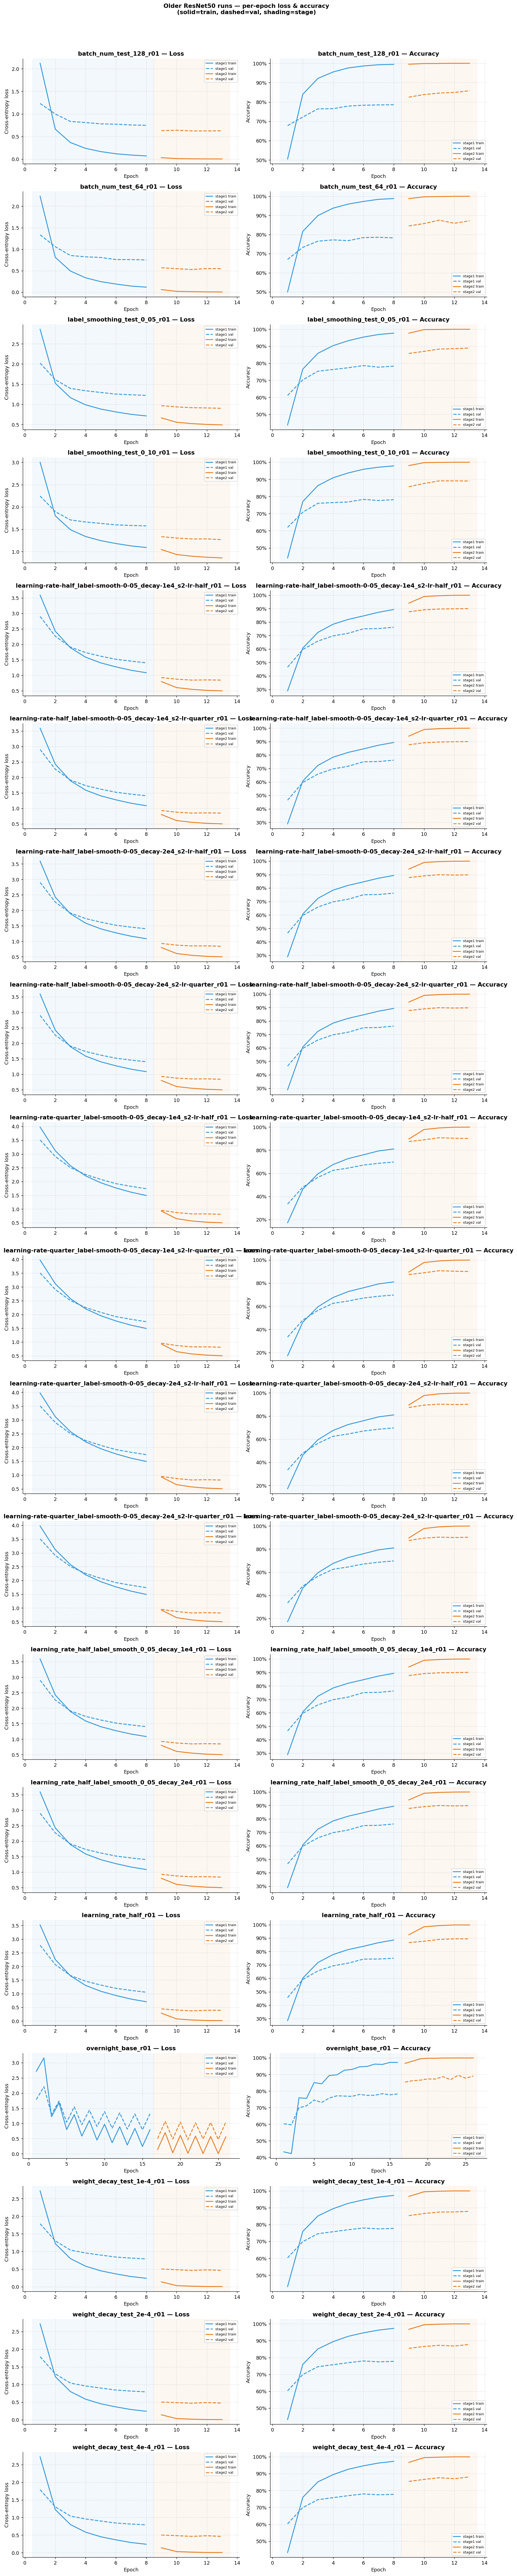

In [5]:
def load_epoch_metrics(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    for col in ['train_loss', 'val_loss', 'train_acc', 'val_acc']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # create a global epoch counter that continues across stages
    df = df.sort_values(['run_label', 'stage', 'epoch']).reset_index(drop=True)
    return df

em = load_epoch_metrics(EPOCH_CSV)

if em.empty:
    print('epoch_metrics.csv not found')
else:
    run_labels = em['run_label'].unique()
    stage_colors = {'stage1': '#3498db', 'stage2': '#e67e22', 'stage3': '#9b59b6', 'stage4': '#27ae60'}

    n = len(run_labels)
    fig, axes = plt.subplots(n, 2, figsize=(14, 3.8 * n), squeeze=False)

    for row_i, run in enumerate(run_labels):
        run_df = em[em['run_label'] == run].copy()
        # build continuous x-axis across stages
        run_df['global_epoch'] = range(1, len(run_df) + 1)

        ax_loss = axes[row_i][0]
        ax_acc  = axes[row_i][1]

        for stage, grp in run_df.groupby('stage', sort=False):
            c = stage_colors.get(stage, '#7f8c8d')
            x = grp['global_epoch']
            ax_loss.plot(x, grp['train_loss'], color=c, lw=1.8,  label=f'{stage} train')
            ax_loss.plot(x, grp['val_loss'],   color=c, lw=1.8,  linestyle='--', label=f'{stage} val')
            ax_acc.plot( x, grp['train_acc'],  color=c, lw=1.8,  label=f'{stage} train')
            ax_acc.plot( x, grp['val_acc'],    color=c, lw=1.8,  linestyle='--', label=f'{stage} val')
            # shade stage regions
            for ax in (ax_loss, ax_acc):
                ax.axvspan(x.iloc[0] - 0.5, x.iloc[-1] + 0.5, alpha=0.06, color=c)

        ax_loss.set_title(f'{run} — Loss', fontweight='bold')
        ax_loss.set_xlabel('Epoch')
        ax_loss.set_ylabel('Cross-entropy loss')
        ax_loss.legend(fontsize=7, loc='upper right')

        ax_acc.set_title(f'{run} — Accuracy', fontweight='bold')
        ax_acc.set_xlabel('Epoch')
        ax_acc.set_ylabel('Accuracy')
        ax_acc.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax_acc.legend(fontsize=7, loc='lower right')

    fig.suptitle('Older ResNet50 runs — per-epoch loss & accuracy\n(solid=train, dashed=val, shading=stage)',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

---
## 3 · Older ResNet50 runs — final accuracy comparison

Best val accuracy and test accuracy per run label, split by stage.

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (23,) + inhomogeneous part.

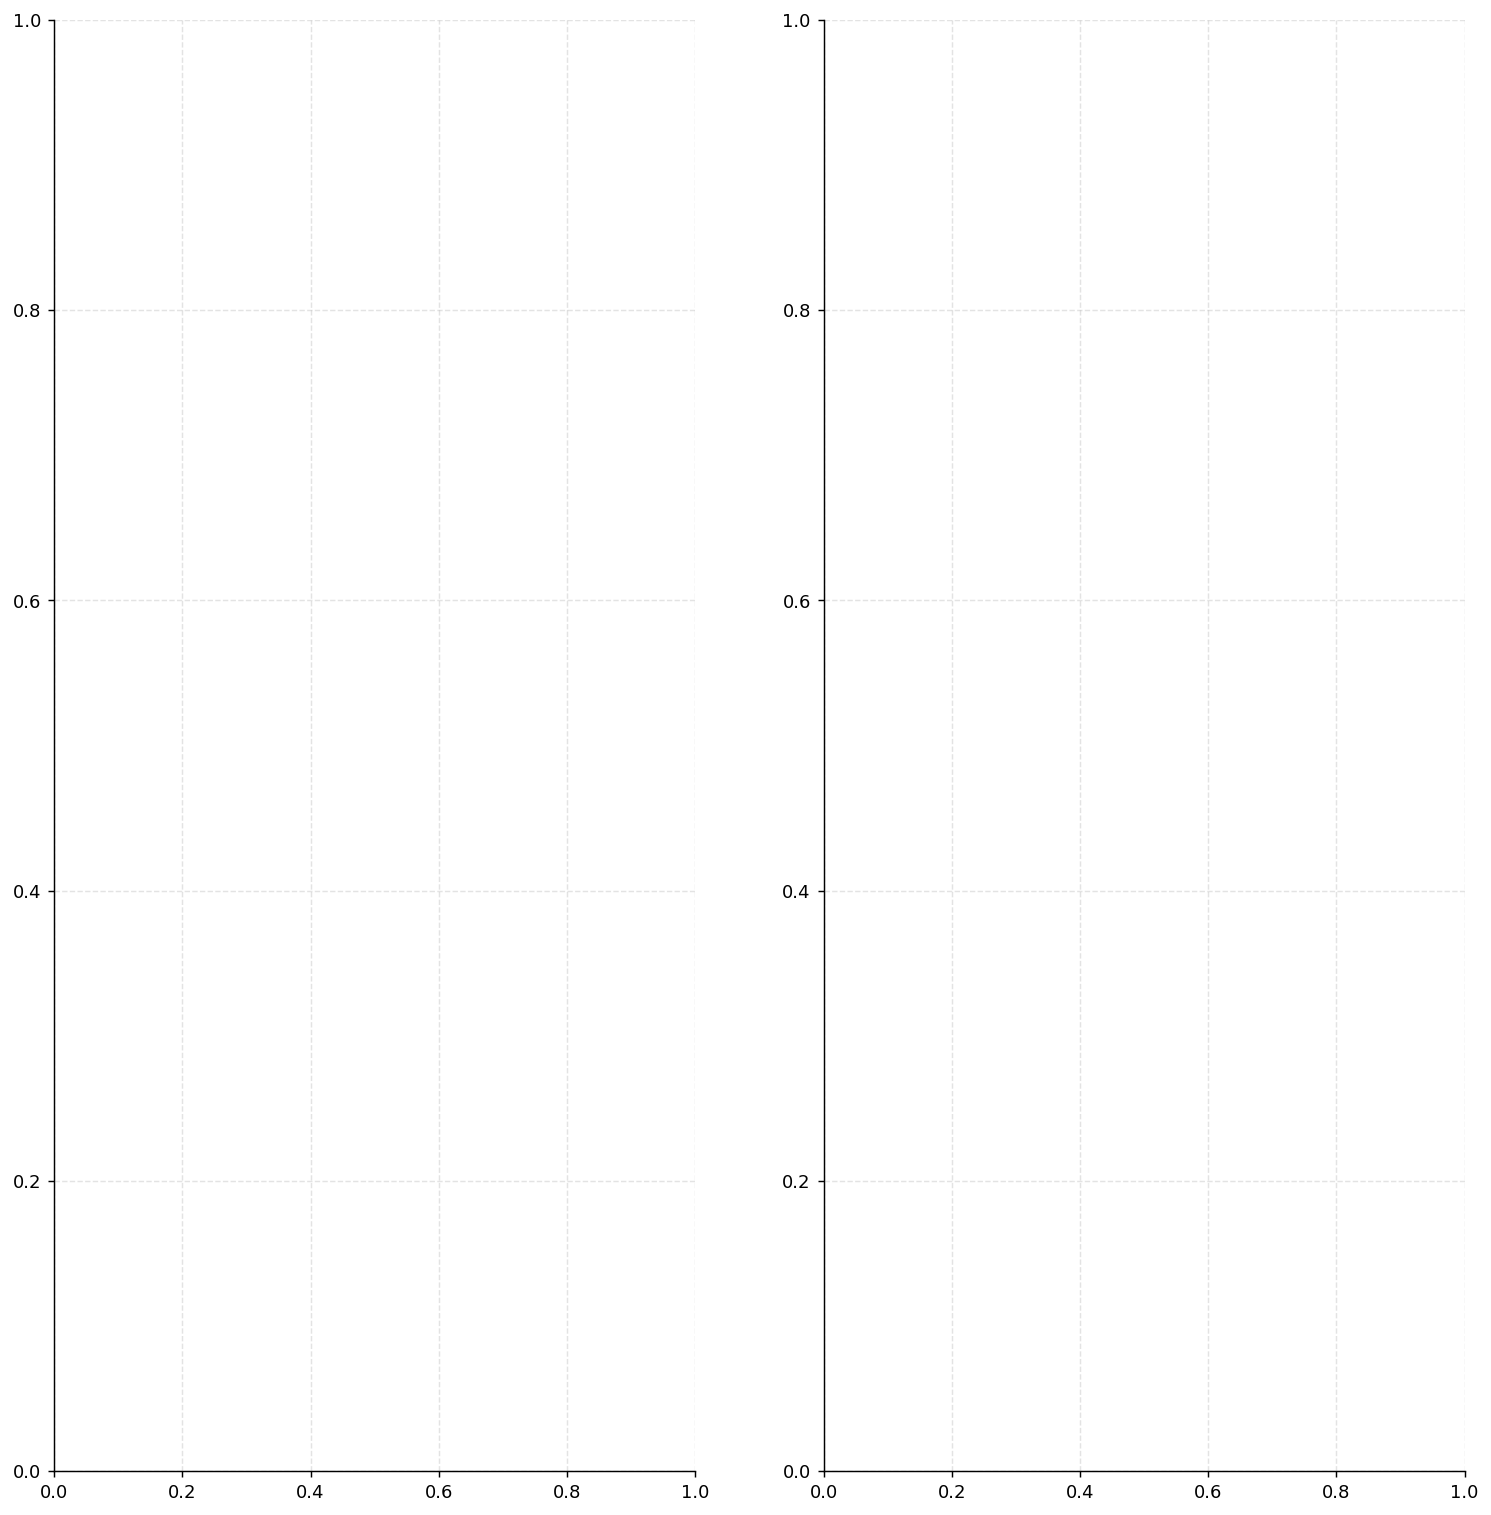

In [6]:
def load_run_summary(path: Path) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame()
    df = pd.read_csv(path)
    for col in ['best_val_acc', 'test_acc']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

rs = load_run_summary(SUMMARY_CSV)

if rs.empty:
    print('run_summary.csv not found')
else:
    # pivot: one row per (run_label, stage)
    stages = rs['stage'].unique()
    run_labels = rs['run_label'].unique()
    x = np.arange(len(run_labels))
    width = 0.35 / max(len(stages), 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(run_labels) * 0.5 + 3)))

    stage_colors_list = ['#3498db', '#e67e22', '#9b59b6', '#27ae60']

    for metric, ax, ylabel in [
        ('best_val_acc', axes[0], 'Best val accuracy'),
        ('test_acc',     axes[1], 'Test accuracy'),
    ]:
        for i, stage in enumerate(stages):
            stage_df = rs[rs['stage'] == stage].set_index('run_label')
            vals = [stage_df.loc[lbl, metric] if lbl in stage_df.index else np.nan
                    for lbl in run_labels]
            offset = (i - len(stages) / 2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width * 0.9,
                          label=stage, color=stage_colors_list[i % len(stage_colors_list)], alpha=0.85)
            ax.bar_label(bars, fmt='{:.3f}', fontsize=6.5, padding=2, rotation=90)

        ax.set_xticks(x)
        ax.set_xticklabels(run_labels, rotation=35, ha='right', fontsize=8)
        ax.set_ylabel(ylabel)
        ax.set_title(ylabel, fontweight='bold')
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
        ax.set_ylim(0, 1.05)
        ax.legend(fontsize=8)

    fig.suptitle('Older ResNet50 runs — final accuracy per run & stage',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 4 · Combined best-accuracy timeline

All sources on one plot — older runs (by start time) followed by autoresearch experiments.

In [ ]:
records = []

# older method: take best stage2 (or highest-stage) val acc per run_label
if not rs.empty:
    best_stage = rs.loc[rs.groupby('run_label')['best_val_acc'].idxmax()]
    for _, row in best_stage.iterrows():
        records.append({
            'source': 'older_resnet50',
            'label': row['run_label'],
            'val_acc': row['best_val_acc'],
            'status': 'older',
        })

# autoresearch subset98
if not df98.empty:
    for _, row in df98.iterrows():
        records.append({
            'source': 'autoresearch_98',
            'label': f"AR98 #{int(row['exp_num'])}",
            'val_acc': row['val_acc'],
            'status': row.get('status', ''),
        })

# autoresearch full555 (different scale — plot separately on right axis)
timeline = pd.DataFrame(records)

if timeline.empty:
    print('No data to plot')
else:
    fig, ax = plt.subplots(figsize=(16, 5))

    source_styles = {
        'older_resnet50':  dict(marker='s', ms=8,  color='#8e44ad'),
        'autoresearch_98': dict(marker='o', ms=6,  color='#2980b9'),
    }
    source_labels_seen = set()

    x_ticks, x_labels = [], []
    for i, row in timeline.reset_index(drop=True).iterrows():
        style = source_styles.get(row['source'], dict(marker='o', ms=6, color='grey'))
        c = STATUS_COLORS.get(row['status'], style['color'])
        lbl = row['source'] if row['source'] not in source_labels_seen else '_nolegend_'
        source_labels_seen.add(row['source'])
        ax.scatter(i, row['val_acc'], color=c, zorder=3,
                   marker=style['marker'], s=style['ms']**2, label=lbl)
        if i % max(1, len(timeline) // 20) == 0:
            x_ticks.append(i)
            x_labels.append(row['label'])

    # running best across all sources
    running_best = timeline['val_acc'].cummax()
    ax.step(range(len(timeline)), running_best, where='post',
            color='#2c3e50', lw=2, zorder=2, label='running best (all sources)')

    # shade regions by source
    source_groups = timeline.groupby('source').apply(lambda g: (g.index[0], g.index[-1]))
    source_shading = {'older_resnet50': '#8e44ad', 'autoresearch_98': '#2980b9'}
    for src, (start, end) in source_groups.items():
        ax.axvspan(start - 0.5, end + 0.5, alpha=0.05, color=source_shading.get(src, 'grey'),
                   label=f'_{src}_region')
        ax.text((start + end) / 2, ax.get_ylim()[0] + 0.005, src.replace('_', ' '),
                ha='center', fontsize=8, color=source_shading.get(src, 'grey'), alpha=0.7)

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=40, ha='right', fontsize=7)
    ax.set_ylabel('Val accuracy')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_title('All runs — val accuracy over time (older method → autoresearch)', fontweight='bold')
    # deduplicate legend
    handles, labels = ax.get_legend_handles_labels()
    seen = {};
    for h, l in zip(handles, labels):
        if not l.startswith('_'): seen[l] = h
    ax.legend(seen.values(), seen.keys(), fontsize=8, loc='lower right')
    plt.tight_layout()
    plt.show()